### 8. Satellite in Low Earth Orbit

The orbits used by satellites as they circle the earth are separated into three classes: High Earth Orbits (HEO) including geosynchronous orbits have an altitude in excess of 36,000 km; Mid Earth Orbits (MEO) range in altitude from 2,000–36,000 km; and Low Earth Orbits (LEO) range from 200–2,000 km. Examples of objects currently in LEO are the International Space Station (altitude 300–400 km), the Hubble Space Telescope (altitude 500 km), and many weather satellites. Objects in LEO complete an orbit in an hour or two. The net force on a satellite in a circular orbit at a height of 500 km above the earth’s surface, neglecting the force of air drag on the satellite, is given by the universal gravitational force from the earth:

$$
F = -\frac{G m M}{r^2}
$$

where $r = R_E + h$ is the position of the satellite, measured from the origin at the center of the earth, $R_E = 6.3781 \times 10^6$ is the radius of the Earth, $G = 6.6743 \times 10^{-11} \, \text{m}^3/(\text{kg} \cdot \text{s}^2)$ is the universal gravitational constant, $M_E = 5.9722 \times 10^{24} \, \text{kg}$ is the mass of the earth, and $m$ is the mass of the satellite, which we will take to be 10,000 kg (this is approximately the mass of the Hubble Space Telescope).

---

**(a) (5 points)** Using Newton’s second law, write an expression to find the orbital speed that the satellite needs in order to maintain a circular orbit at a height of $h = 500$ km. Note that, for what follows, it is important to make your calculation using at least 5 significant figures — we need a highly accurate orbital speed in order to see relevant changes to the orbit on the order of kilometers. Put this into your code.

---

**(b) (5 points)** Divide your equations of motion into four first order equations in $(x, y)$ positions and velocities, and write code to calculate all four as a function of time for an initial position and velocity consistent with the orbit given in part (a).

---

**(c) (5 points)** For a duration corresponding to 5 complete orbits, make two plots: the altitude (height above the earth’s surface, in km) of the satellite as a function of time (in minutes or hours); and the y-position as a function of x-position.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
#Setting up Known Constants
G = 6.6743e-11 #Gravitational Constant (Nm^2/kg^2) 
M_earth = 5.9722e24 #Mass of Earth (kg)
R_earth = 6.3781e6 #Radius of Earth (m)
M_satellite = 10000 #Mass of Satellite (kg)
altitude = 500e3 #Altitude of Satellite (m) (Above R_earth)

r = R_earth + altitude #Defining the position of the satellite (m)

v_circular_orbit = np.sqrt(G * M_earth / r) #Calculating the orbital speed to maintain circular orbit
print(f"Orbital velocity: {v_circular_orbit:.5f} m/s") #To 5 Significant Figures

Orbital velocity: 7612.64873 m/s


In [3]:
def satellite_motion(initialconditions, t): #Creating a function that defines the position and velocity vectors according to initial inputs
    x, y, vx, vy = initialconditions #Unpacking all of the givens (x position, y position, x initial velocity, y initial velocity)
    vx = vx #Calculating dx/dt in the x
    vy = vy #Calculating dy/dt in the y
    r = np.sqrt(x**2 + y**2) #Calculating the current distance away from the center of the Earth
    ax = -G * M_earth * x / r**3 #Calculating dv/dt in the x
    ay = -G * M_earth * y / r**3 #Calculating dv/dt in the y
    return [vx, vy, ax, ay] #Returning the derivatives of each initial condition variable in order to plot new values over time

initial_conditions = [r, 0, 0, v_circular_orbit] #Setting initial conditions (satellite a distance r from the Earth in the +x, with a vertical velocity for circular orbit)

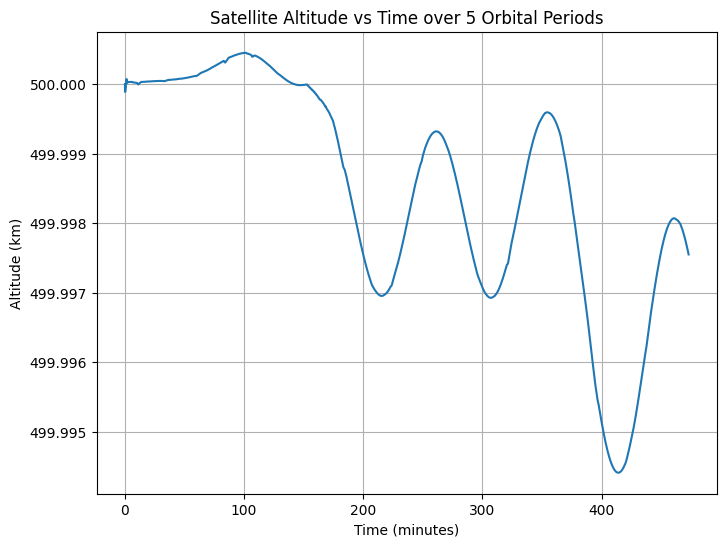

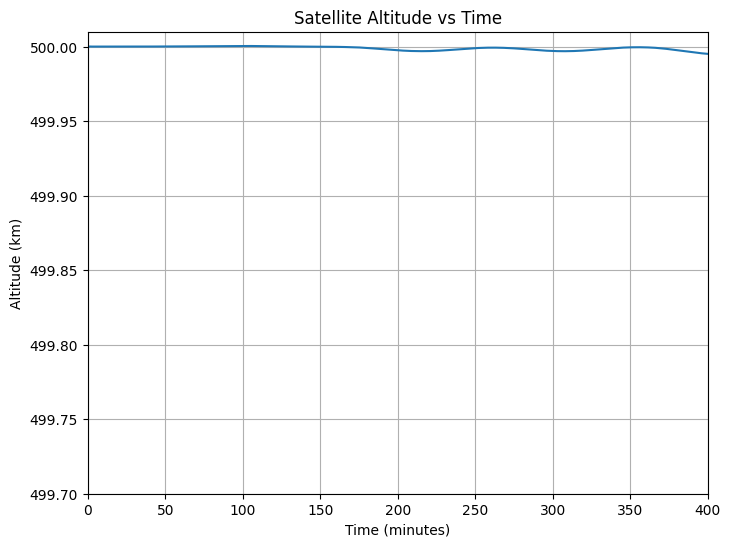

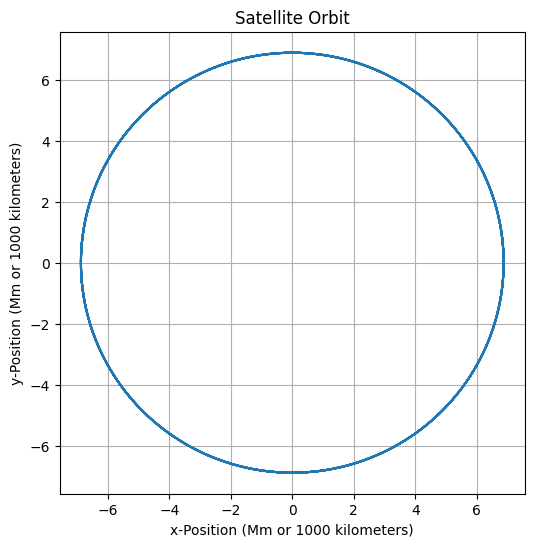

In [4]:
T = 2 * np.pi * r / v_circular_orbit #Orbital Period (seconds)
t_max = 5 * T #5 Orbital Periods
n_points = 10000 #Creating a number of points to be plotted
t = np.linspace(0, t_max, n_points) #Creating the array of all the points to plot between the 5 orbits

solution = odeint(satellite_motion, initial_conditions, t) #Solving the equations created above to get the positions and velocities at each timestep
x, y, vx, vy = np.transpose(solution) #Transposing the array that odeint returned because it returns it in a form where each column corresponds to a specific variable, not each row

altitude_km = (np.sqrt(x**2 + y**2) - R_earth) / 1000 #Putting the altitude into km (r-R) (1000m = 1 km)
t_minutes = t / 60 #Putting the time into minutes (60 seconds = 1 minute)

AltitudeGraph = plt.figure(figsize=(8,6)) #Plotting altitude in kilometers vs time in minutes
ax = AltitudeGraph.add_subplot(1, 1, 1)
ax.plot(t_minutes, altitude_km)
ax.get_yaxis().get_major_formatter().set_useOffset(False)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Satellite Altitude vs Time over 5 Orbital Periods')
ax.grid()
plt.show()

AltitudeGraphCompare = plt.figure(figsize=(8,6)) #Plotting altitude in kilometers vs time in minutes
ax = AltitudeGraphCompare.add_subplot(1, 1, 1)
ax.plot(t_minutes, altitude_km)
ax.get_yaxis().get_major_formatter().set_useOffset(False)
ax.set_xlabel('Time (minutes)')
ax.set_xlim(0,400)
ax.set_ylim(499.7,500.01)
ax.set_ylabel('Altitude (km)')
ax.set_title('Satellite Altitude vs Time')
ax.grid()
plt.show()

OrbitalGraph = plt.figure(figsize=(6,6)) #Plotting y position in Mm vs x position in Mm
ax = OrbitalGraph.add_subplot(1, 1, 1)
ax.plot(y/1e6, x/1e6)
ax.set_xlabel('x-Position (Mm or 1000 kilometers)')
ax.set_ylabel('y-Position (Mm or 1000 kilometers)')
ax.set_title('Satellite Orbit')
ax.grid()
plt.show()

### 9. Air Drag on a Satellite in Low Earth Orbit (15 points)

LEO satellites experience non-negligible air drag; unless this force is corrected for, the satellite’s orbit will spiral down toward the earth over the course of weeks or months. The force of air drag on the satellite should be well-modeled by (as in Prob. 7):

$$
F = \frac{1}{2} \rho C A v \vec{v}
$$

where $C \approx 2$ is the drag coefficient, $\rho = 1.70 \times 10^{-11} \ \text{kg/m}^3$ is the atmospheric density at an altitude of 500 km, $A = 50 \ \text{m}^2$ is the cross-sectional area of the satellite, and $\vec{v}$ is the velocity vector of the satellite.

Add the force of air drag to your satellite orbit calculation in Problem 8, and once again plot the trajectory and the altitude as functions of time. How much altitude does the satellite lose in a day? How long before the air drag on the satellite causes it to lose 10 km of altitude? This is the point at which correction to the orbit is necessary.



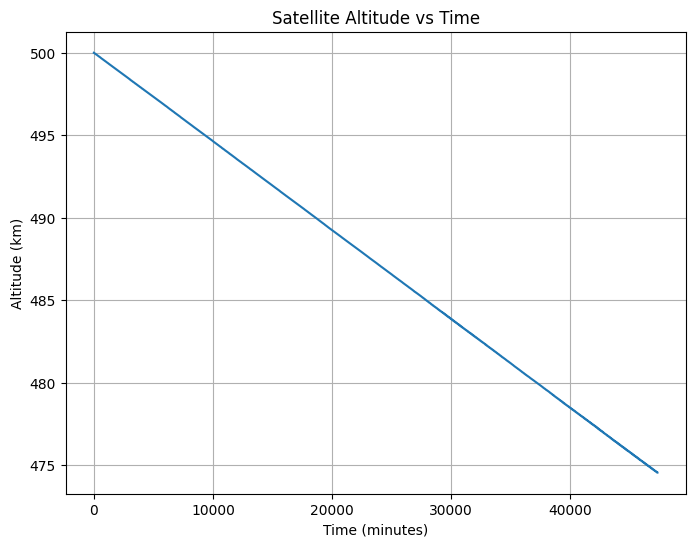

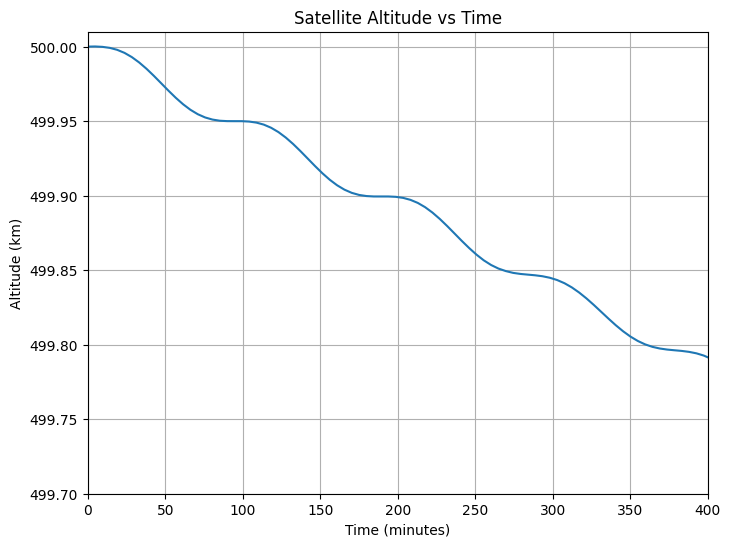

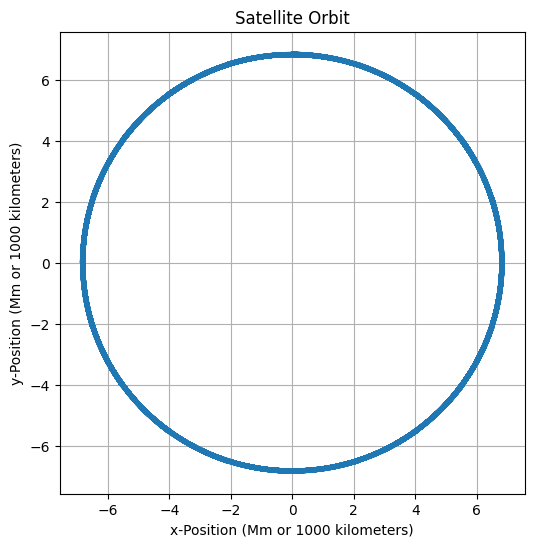

In [5]:
C = 2 #Drag Coefficient
rho = 1.7e-11 #Atmospheric Density at an altitude of 500 km (kg/m^3)
A = 50 #Cross-sectional Area of the Satellite (m^2)

def satellite_motion_drag(initialconditions, t):
    x, y, vx, vy = initialconditions #Unpacking all of the givens (x position, y position, x initial velocity, y initial velocity)
    vx = vx #Calculating dx/dt in the x
    vy = vy #Calculating dy/dt in the y
    r = np.sqrt(x**2 + y**2) #Calculating the current distance away from the center of the Earth
    v = np.sqrt(vx**2 + vy**2) #Since velocity is also now used in the calculation, we need the velocity magnitude
    ax = -G * M_earth * x / r**3 - (0.5 * rho * C * A * v * vx / M_satellite) #Calculating dv/dt in the x
    ay = -G * M_earth * y / r**3 - (0.5 * rho * C * A * v * vy / M_satellite) #Calculating dv/dt in the y
    return [vx, vy, ax, ay] #Returning the derivatives of each initial condition variable in order to plot new values over time

t = np.linspace(0, 100*t_max, n_points) #Creating the array of all the points to plot between the 5 orbits
solution = odeint(satellite_motion_drag, initial_conditions, t) #Solving the equations created above to get the positions and velocities at each timestep
x, y, vx, vy = np.transpose(solution) #Transposing the array that odeint returned because it returns it in a form where each column corresponds to a specific variable, not each row

altitude_km = (np.sqrt(x**2 + y**2) - R_earth) / 1000 #Putting the altitude into km (r-R) (1000m = 1 km)
t_minutes = t / 60 #Putting the time into minutes (60 seconds = 1 minute)

AltitudeGraph2 = plt.figure(figsize=(8,6)) #Plotting altitude in kilometers vs time in minutes
ax = AltitudeGraph2.add_subplot(1, 1, 1)
ax.plot(t_minutes, altitude_km)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Satellite Altitude vs Time')
ax.grid()
plt.show()

AltitudeGraphCompare2 = plt.figure(figsize=(8,6)) #Plotting altitude in kilometers vs time in minutes
ax = AltitudeGraphCompare2.add_subplot(1, 1, 1)
ax.plot(t_minutes, altitude_km)
ax.get_yaxis().get_major_formatter().set_useOffset(False)
ax.set_xlabel('Time (minutes)')
ax.set_xlim(0,400)
ax.set_ylim(499.7,500.01)
ax.set_ylabel('Altitude (km)')
ax.set_title('Satellite Altitude vs Time')
ax.grid()
plt.show()

OrbitalGraph2 = plt.figure(figsize=(6,6)) #Plotting y position in Mm vs x position in Mm
ax = OrbitalGraph2.add_subplot(1, 1, 1)
ax.plot(y/1e6, x/1e6)
ax.set_xlabel('x-Position (Mm or 1000 kilometers)')
ax.set_ylabel('y-Position (Mm or 1000 kilometers)')
ax.set_title('Satellite Orbit')
ax.grid()
plt.show()

In [6]:
altitude_day_start = altitude_km[0] #Finding the starting altitude
for t in range(len(t_minutes)):
    if t_minutes[t] > 1440:
        altitude_day_end = altitude_km[t] #Finding the final altitude after 1 day of orbit with drag
        break
altitude_lost_day = altitude_day_start - altitude_day_end #Calculating the altitude lost in 1 day
print(f"Altitude Lost in a day: {altitude_lost_day:.4f} km") #Printing out the altitude lost in a day

for t in range(len(t_minutes)): #Iterating through all the times
    if altitude_day_start - altitude_km[t] >= 10: #Finding when the altitude difference is greater than 10
        print(f"The time in which it takes to lose 10 km is: {t_minutes[t]:.2f} minutes or {t_minutes[t]/60:.2f} hours") #Printing out the time
        break

Altitude Lost in a day: 0.7685 km
The time in which it takes to lose 10 km is: 18607.96 minutes or 310.13 hours
